# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [4]:
df.shape

(10886, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       10886 non-null  int64  
 1   holiday      10886 non-null  int64  
 2   workingday   10886 non-null  int64  
 3   weather      10886 non-null  int64  
 4   temp         10886 non-null  float64
 5   atemp        10886 non-null  float64
 6   humidity     10886 non-null  int64  
 7   windspeed    10886 non-null  float64
 8   casual       10886 non-null  int64  
 9   registered   10886 non-null  int64  
 10  count        10886 non-null  int64  
 11  date         10886 non-null  object 
 12  day          10886 non-null  int32  
 13  week         10886 non-null  UInt32 
 14  weekday_num  10886 non-null  int32  
 15  weekday      10886 non-null  object 
 16  year         10886 non-null  int32  
 17  month        10886 non-null  int32  
 18  hour       

In [6]:
# 10886 рядків, 19 колонок
# Дані мають погодинну деталізацію

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [7]:
daily_bike_rentals = df.groupby('date')['count'].sum()
daily_bike_rentals

,count
date,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-15,5047
2012-12-16,3786
2012-12-17,4585


In [8]:
# or
grouped_daily = df['count'].resample('D').sum()
grouped_daily

,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-15,5047
2012-12-16,3786
2012-12-17,4585


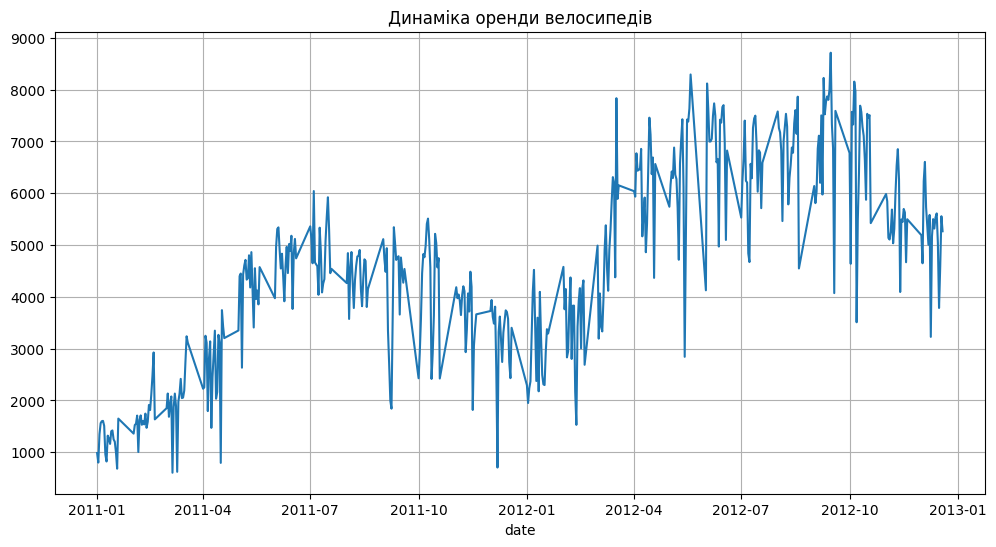

In [9]:
daily_bike_rentals.plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів'
    )
plt.grid(True);

**Answer**

Заломи через надто високу гранулярність. Бажано згрупувати за місяцем чи кварталом.

Зріст у другий рік, ймовірно спричинений розвитком бізнесу.

У зимові місяці менше оренд. У сезони Мonsoon та Post-monsoon більше замовлень.

Оскільки після аномально високих значень йде різкий спад, можливо, це вихідні дні або свята, за якими йдуть робочі.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [10]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['season_name'] = df['month'].apply(get_season)
df['season_name']

,season_name
datetime,
2011-01-01 00:00:00,Winter
2011-01-01 01:00:00,Winter
2011-01-01 02:00:00,Winter
2011-01-01 03:00:00,Winter
2011-01-01 04:00:00,Winter
...,...
2012-12-19 19:00:00,Winter
2012-12-19 20:00:00,Winter
2012-12-19 21:00:00,Winter


In [11]:
seasonal_bike_rentals = df.groupby(['year', 'season_name'])['count'].mean().unstack()
seasonal_bike_rentals

season_name,Monsoon,Post-Monsoon,Summer,Winter
year,,,,
2011,189.469522,165.105379,124.513633,88.206302
2012,283.098136,256.271131,243.285714,162.447214


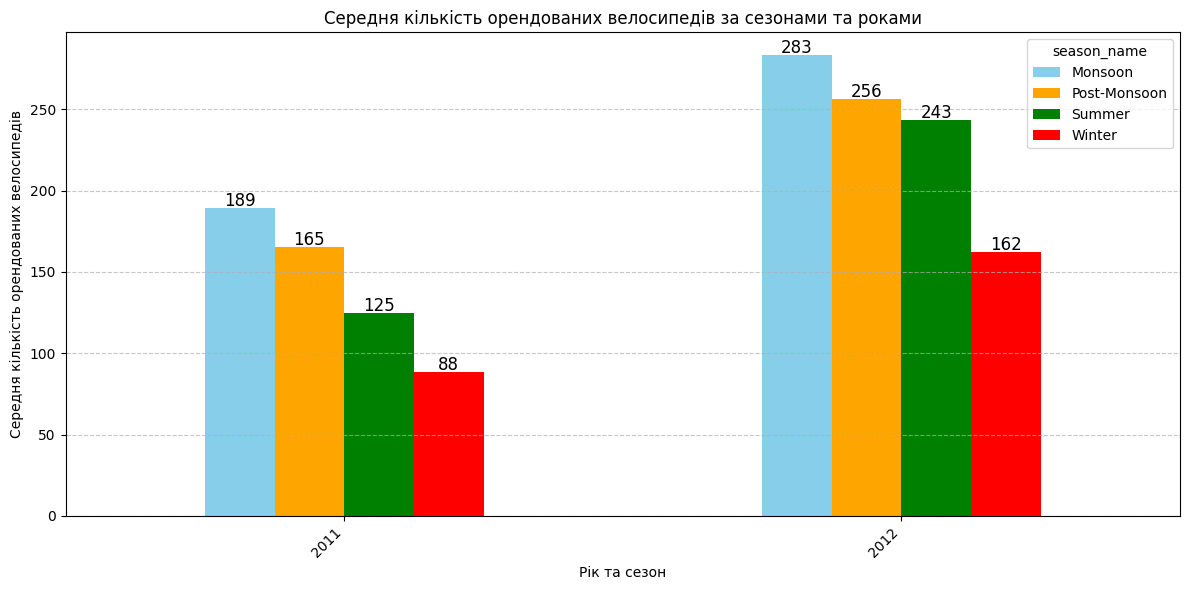

In [12]:
ax = seasonal_bike_rentals.plot.bar(
    figsize=(12, 6),
    color=['skyblue', 'orange', 'green', 'red'])

plt.title('Середня кількість орендованих велосипедів за сезонами та роками')
plt.xlabel('Рік та сезон')
plt.ylabel('Середня кількість орендованих велосипедів')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [13]:
print(round(189 / 88, 2), round(283 / 162, 2))

2.15 1.75


**Відповіді**

В який квартал найбільша середня кількість оренди велосипедів? - Мусон

Як ви можете пояснити таку сезонну закономірність? - Взимку в Індії приємна і суха погода, люди, мабуть, надають перевагу прогулянкам. У сезон мусонів дощі, що сприяє бажанню швидше дібратися до місця призначення.

У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталaми? - Приблизко в 2 рази

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [14]:
monthly_bike_rentals = df.groupby('month')['count'].mean()
monthly_bike_rentals

,count
month,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


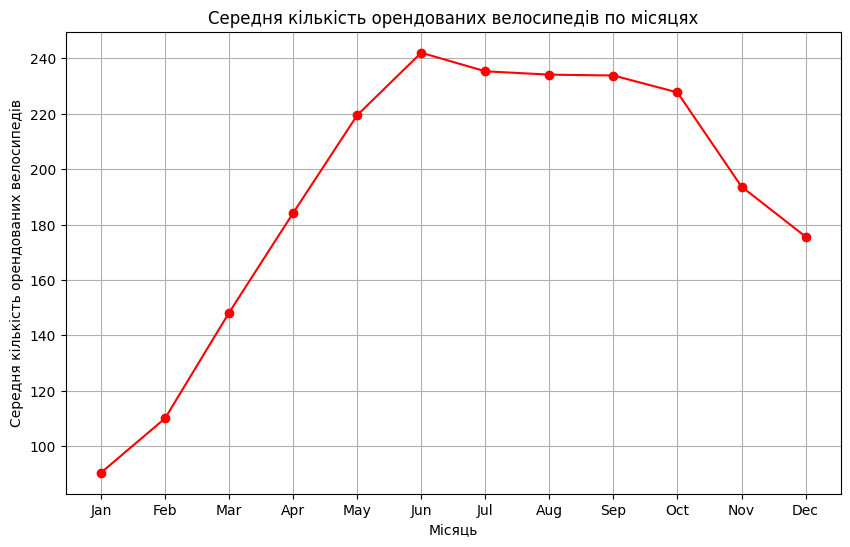

In [15]:
ax = monthly_bike_rentals.plot(
    kind='line',
    color='red',
    marker='o',
    figsize=(10, 6),
    title='Середня кількість орендованих велосипедів по місяцях',
    xlabel='Місяць',
    ylabel='Середня кількість орендованих велосипедів',
    grid=True
)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']);


**Відповіді**

В які місяці спостерігається пік та спад оренди? - Пік - червень-серпень; спад - листопад-березень

Чи збігається ця закономірність з результатами з попереднього завдання? Так

Як може вплинути клімат на оренду велосипедів протягом року? Повені перешкоджають руху, жаркий період - некомфортно пересуватися на відкритому транспортному засобі

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

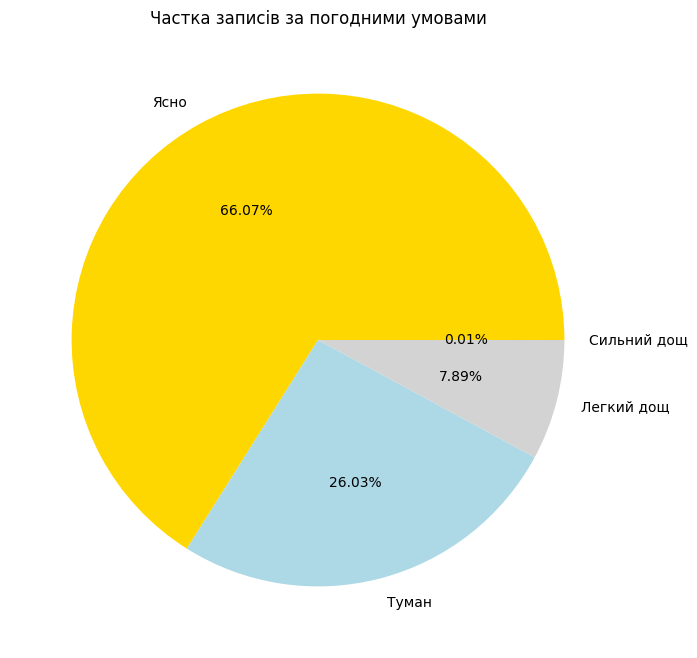

In [16]:
weather_counts = df['weather'].value_counts()
weather_counts

,count
weather,
1,7192
2,2834
3,859
4,1


In [17]:
weather_labels = {1: 'ясно', 2: 'туман', 3: 'легкий дощ', 4: 'сильний дощ'}

In [18]:
weather_colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

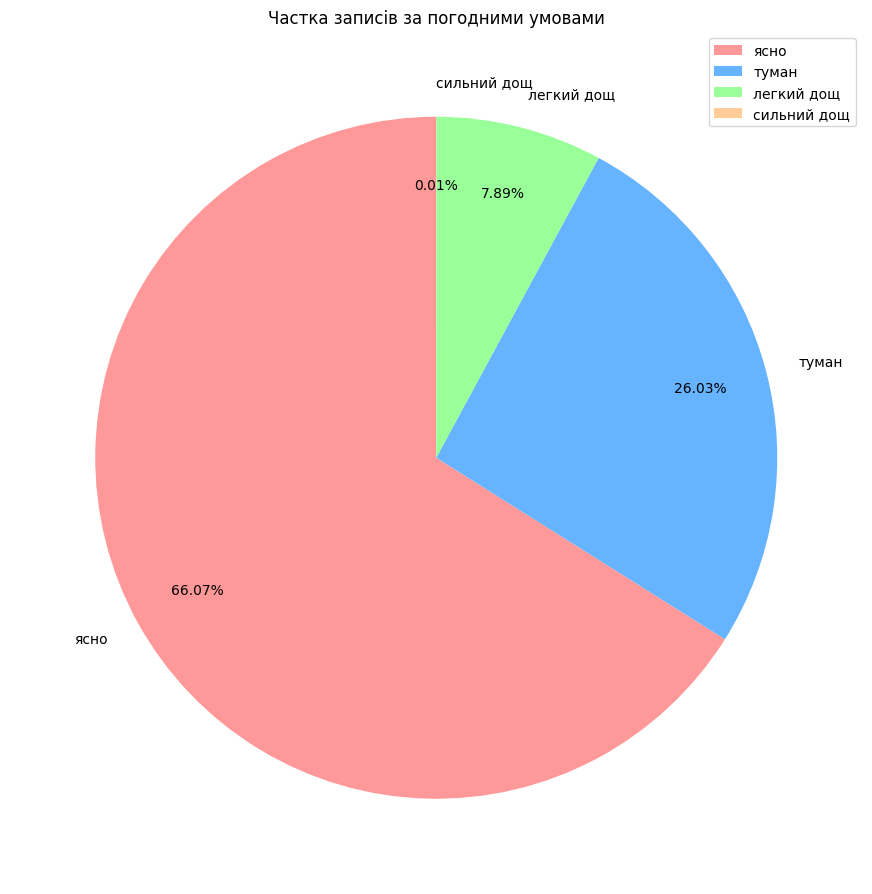

In [19]:
weather_counts.plot.pie(labels=[weather_labels[i] for i in weather_counts.index],
                             autopct='%1.2f%%',
                             colors=weather_colors,
                             figsize=(11, 18),
                             startangle=90,
                             legend=True,
                        pctdistance=0.8,
                             title='Частка записів за погодними умовами',
                             ylabel='');

Яка погода переважає в датасеті? - Ясна

Чи є дні із сильним дощем? Яка їх частка? - 0.01%

Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів? - Ясна погода сприяє підвищенню запиту на оренду

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [20]:
df['weather_label'] = df['weather'].map(weather_labels)

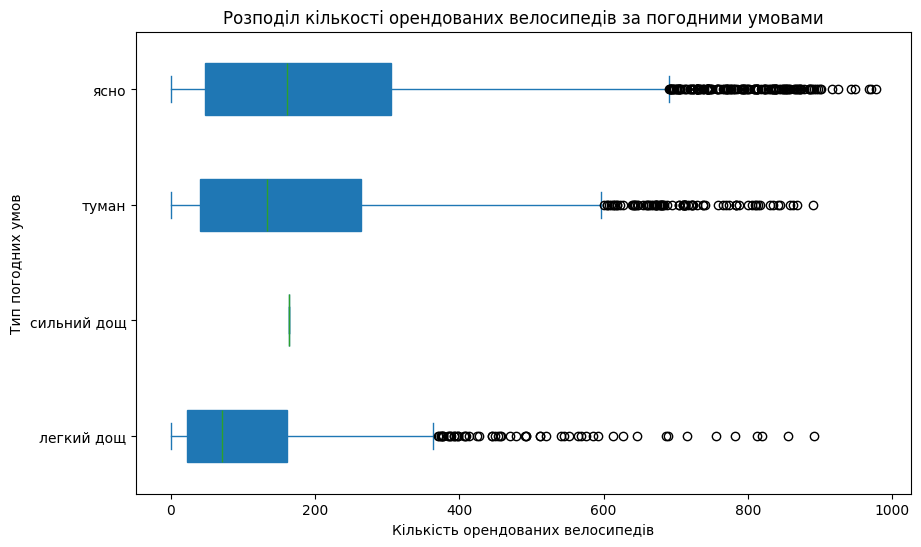

In [21]:
ax = df.plot.box(column='count', by='weather_label', vert=False, figsize=(10, 6), patch_artist=True)

plt.title('Розподіл кількості орендованих велосипедів за погодними умовами')
plt.suptitle('')
plt.xlabel('Кількість орендованих велосипедів')
plt.ylabel('Тип погодних умов');


При якій погоді найбільший розкид у кількості оренди? - При ясній

Чи є викиди (outliers) в даних? При якій погоді? - Всіх, крім сильного дощу

При якій погоді медіанне значення оренди найвище? - Оскільки при сильному дощу немає достатньої кількості даних для занчущого аналізу, при ясній погоді найвище медіанне значення

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

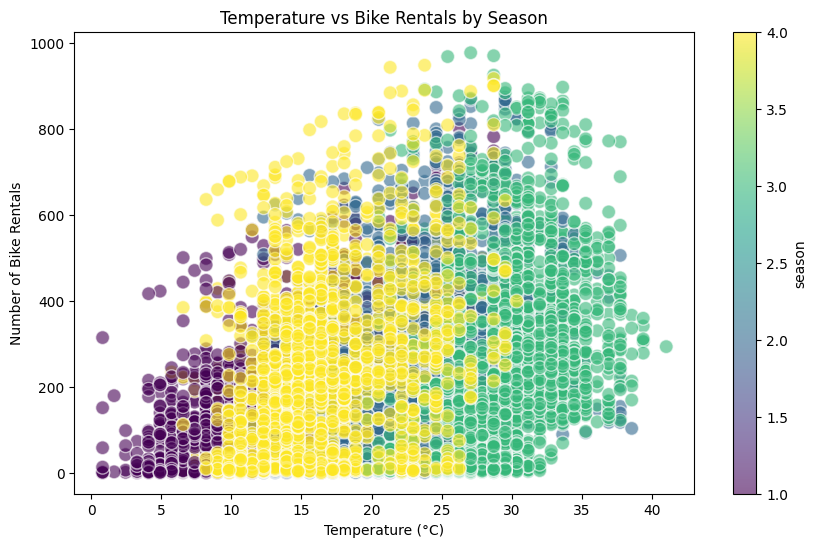

In [22]:
ax = df.plot(kind='scatter', x='temp', y='count', c='season',
             colormap='viridis',
             alpha=0.6, figsize=(10, 6), edgecolors="w", s=100,
             title = 'Temperature vs Bike Rentals by Season',
             xlabel = 'Temperature (°C)',
             ylabel= 'Number of Bike Rentals');

Чи є зв'язок між температурою та кількістю оренди? Який? - Позитивний лінійний зв'язок, кореляція

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

/tmp/ipython-input-37314/1070580772.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_bike_rentals = df.groupby('weekday')[['casual', 'registered']].mean()


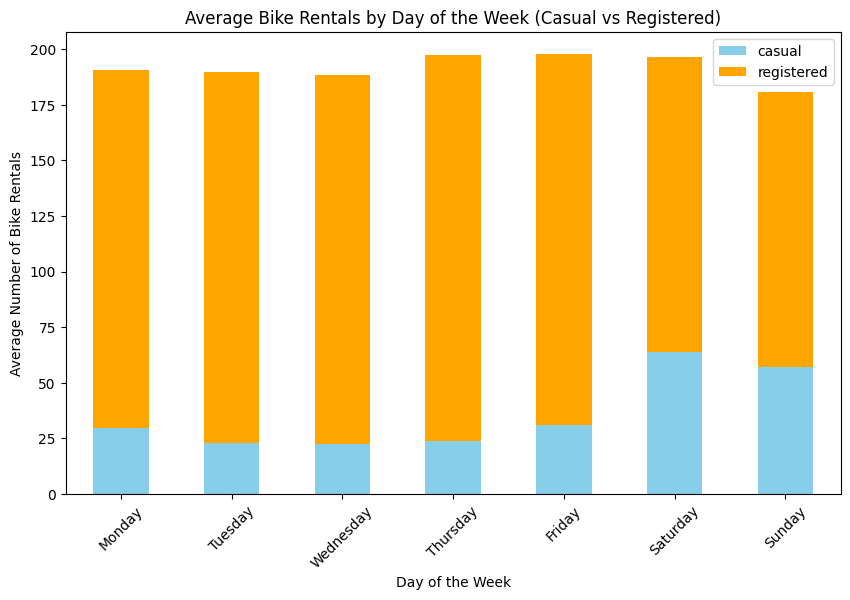

In [24]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df['weekday'] = pd.Categorical(df['weekday'], categories=days_order, ordered=True)

daily_bike_rentals = df.groupby('weekday')[['casual', 'registered']].mean()

ax = daily_bike_rentals.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'orange'])

ax.set_title('Average Bike Rentals by Day of the Week (Casual vs Registered)')
ax.set_xlabel('Day of the Week')
ax.set_ylabel('Average Number of Bike Rentals')
plt.xticks(rotation=45);

В які дні тижня більше оренд від зареєстрованих користувачів? Thurday, Friday, Sunday

Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня? Прогулянки на вихідних або поїздка за покупками, необхідність транспорту, відвідування сім'ї в кінці тижня